# Data Structures — 2310214L
### How CO1 and CO2 are used in Datapath Bench

Everything in `src/ds/` is written by hand. Each container also does a real job inside
the processor — none of them exists only to demonstrate a topic.

| | Outcome | Used for |
|---|---|---|
| **CO1** | Develop applications using arrays | Registers, instruction memory, pixel buffer |
| **CO2** | Choose a suitable type of linked list | Output log, listing, and the rewind history |

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle, FancyArrowPatch, Circle

PAPER  = "#FAF8F3"; BAND = "#F1EEE6"
NAVY   = "#1B2A34"; INK  = "#1C2320"
COPPER = "#B25E1C"; TEAL = "#0C5E50"
LINE   = "#C9C2B2"; MUTED = "#7C8781"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 9})

def canvas(w=11, h=3.2, xlim=(0, 110), ylim=(0, 32)):
    fig, ax = plt.subplots(figsize=(w, h), dpi=150)
    fig.patch.set_facecolor(PAPER); ax.set_facecolor(PAPER)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)
    return fig, ax

def box(ax, x, y, w, h, title="", sub="", fc="white", ec=None, tc=None, fs=9, r=0.4):
    ec = ec or LINE; tc = tc or INK
    ax.add_patch(FancyBboxPatch((x, y), w, h,
                 boxstyle="round,pad=0,rounding_size=%s" % r,
                 linewidth=1.3, edgecolor=ec, facecolor=fc, zorder=2))
    if title:
        ax.text(x + w/2, y + h/2 + (1.4 if sub else 0), title, ha="center", va="center",
                fontsize=fs, color=tc, weight="bold", zorder=3)
    if sub:
        ax.text(x + w/2, y + h/2 - 2.0, sub, ha="center", va="center",
                fontsize=fs-1.6, color=MUTED, zorder=3)

def arrow(ax, x1, y1, x2, y2, color=None, lw=1.4, style="-|>", ls="-"):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle=style,
                 mutation_scale=11, linewidth=lw, color=color or MUTED,
                 linestyle=ls, zorder=4, shrinkA=1, shrinkB=1))

def label(ax, x, y, t, color=None, fs=8.2, ha="center", weight="normal", style="normal"):
    ax.text(x, y, t, ha=ha, va="center", fontsize=fs,
            color=color or MUTED, weight=weight, style=style, zorder=5)

print('diagram helpers ready')

diagram helpers ready


---
## CO1 · Develop applications using arrays

An array is used wherever something is identified by **its position**. The register
number *is* the index, so reading R5 is a single step. A linked list would force a walk
from the head on every instruction.

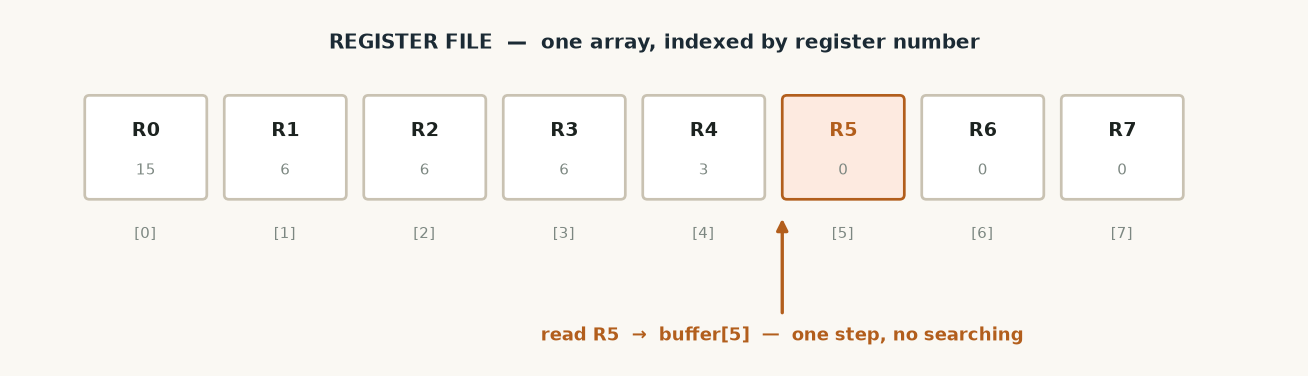

In [ ]:
fig, ax = canvas(h=3.0, ylim=(0, 30))
vals = [15, 6, 6, 6, 3, 0, 0, 0]
for i, v in enumerate(vals):
    hot = (i == 5)
    box(ax, 6 + i*12, 14, 10.5, 9, "R%d" % i, str(v),
        fc="#FDEAE0" if hot else "white",
        ec=COPPER if hot else LINE, tc=COPPER if hot else INK)
    label(ax, 11.2 + i*12, 11, "[%d]" % i, fs=7.4)
label(ax, 55, 27.5, "REGISTER FILE  \u2014  one array, indexed by register number",
      color=NAVY, fs=9.5, weight="bold")
arrow(ax, 66, 4, 66, 12.5, COPPER, 1.6)
label(ax, 66, 2.2, "read R5  \u2192  buffer[5]  \u2014  one step, no searching",
      color=COPPER, fs=8.6, weight="bold")
plt.show()

| Location | File | Indexed by |
|---|---|---|
| Register file R0–R7 | `src/core/RegisterFile.h` | register number |
| Instruction memory | `src/core/CPU.cpp` | the program counter |
| Screen pixel buffer | `src/ui/Canvas.cpp` | `row × width + column` |

```cpp
Register gp_[NUM_GP_REGISTERS];                    // a plain fixed array

void Canvas::setPixel(int x, int y, Pixel p) {
    if (inBounds(x, y)) buffer_[y * width_ + x] = p;   // 1-D array as a 2-D grid
}
```

---
## CO2 · Choose a suitable type of linked list

Two types are used, and the choice is driven by **direction of travel**.

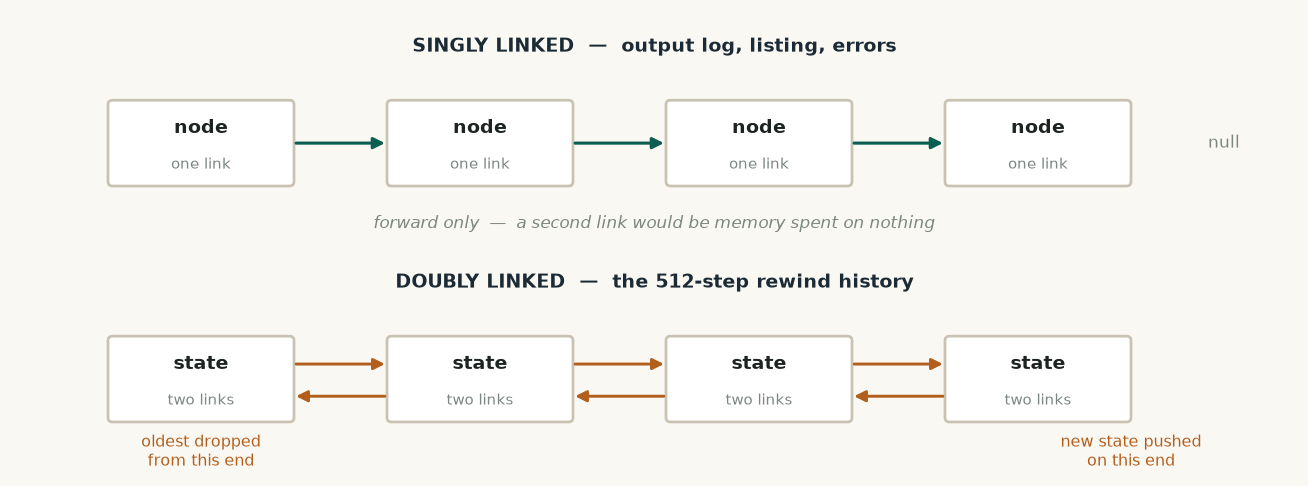

In [ ]:
fig, ax = canvas(h=3.9, ylim=(0, 42))
label(ax, 55, 39, "SINGLY LINKED  \u2014  output log, listing, errors", color=NAVY, fs=9.3, weight="bold")
for i in range(4):
    box(ax, 8 + i*24, 26, 16, 8, "node", "one link", fc="white")
    if i < 3: arrow(ax, 24 + i*24, 30, 32 + i*24, 30, TEAL, 1.5)
label(ax, 104, 30, "null", fs=8, color=MUTED)
label(ax, 55, 22.5, "forward only  \u2014  a second link would be memory spent on nothing", fs=8, style="italic")
label(ax, 55, 17, "DOUBLY LINKED  \u2014  the 512-step rewind history", color=NAVY, fs=9.3, weight="bold")
for i in range(4):
    box(ax, 8 + i*24, 4, 16, 8, "state", "two links", fc="white")
    if i < 3:
        arrow(ax, 24 + i*24, 9.4, 32 + i*24, 9.4, COPPER, 1.4)
        arrow(ax, 32 + i*24, 6.4, 24 + i*24, 6.4, COPPER, 1.4)
label(ax, 16, 1.2, "oldest dropped\nfrom this end", color=COPPER, fs=7.6)
label(ax, 96, 1.2, "new state pushed\non this end", color=COPPER, fs=7.6)
plt.show()

**Singly linked** — the output log, the assembled listing, the error list, and the
chains inside each hash bucket. The length is unknown in advance and each is only read
forwards, so one link per node is all that is needed.

**Doubly linked** — the execution history, which is what makes the step-backward
button work. New states arrive at one end and the oldest is discarded from the other,
so both ends must be reachable.

```cpp
void pushBack(const T& value) {
    Node* n = new Node(value);
    n->prev = tail_;                    // links both ways
    if (tail_) tail_->next = n; else head_ = n;
    tail_ = n;
    ++size_;
}
```

---
## Held back for later parts

This notebook covers **CO1 and CO2 only** — the deliberate scope of the first working
prototype. The remaining outcomes are planned work, listed here so the omission reads
as planning rather than a gap.

| Outcome | Topic | Where it will be used |
|---|---|---|
| CO3 | Stack and queue | The call stack for CALL/RET; the instruction fetch queue |
| CO4 | Searching and sorting | Ordering the memory dump; binary-search breakpoints |
| CO5 | Hashing | The assembler symbol table and sparse memory |

---
*Datapath Bench — an integrated SY B.Tech project.*
*Vivek Dhamale · Pranjal Bhandari · Sanika Patil · Mrudula Bongulwar.*
*Guide: Mrs. Jaya S. Mane, Assistant Professor, Software Engineering Department.*